# scan-like閾値の探索

このNotebookは、M4の人手レビューゲートのために、閾値を適用しない60秒のsource-window観測を可視化します。トラフィックの分類や閾値選択は行いません。

## 1. データの読み込み

In [27]:
import math
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

japanese_font_candidates = ('Hiragino Sans', 'Noto Sans CJK JP', 'Noto Serif CJK JP', 'IPAexGothic', 'YuGothic', 'Meiryo')
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
japanese_font = next((font for font in japanese_font_candidates if font in available_font_names), None)
if japanese_font is None:
    raise RuntimeError('日本語グリフを含むMatplotlibフォントが見つかりません')
plt.rcParams['font.family'] = japanese_font
plt.rcParams['axes.unicode_minus'] = False

def resolve_analysis_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src' / 'mawi_global_analysis').is_dir():
            return candidate
    return Path.cwd()

root = Path(os.environ.get('MAWI_ANALYSIS_ROOT', resolve_analysis_root())).resolve()
dataset_id = os.environ.get('MAWI_DATASET_ID', '202604081400')
run_name = os.environ.get('MAWI_RUN_NAME', 'threshold_exploration')
windows_path = (
    root
    / 'results'
    / dataset_id
    / run_name
    / "source_scan_windows.csv"
)

if not windows_path.is_file():
    raise FileNotFoundError(
        f"source_scan_windows.csv が見つかりません: {windows_path}. "
        "MAWI_ANALYSIS_ROOT / MAWI_DATASET_ID / MAWI_RUN_NAME を設定してください。"
    )

windows = pd.read_csv(windows_path)

broad_plot = windows.loc[
    (windows['syn_initiated_flow_count'] > 0)
    & (windows['unique_targets'] > 0)
]
broad_x_max = broad_plot['syn_initiated_flow_count'].max()
broad_y_max = broad_plot['unique_targets'].max()
broad_x_limits = (1, 10 ** math.ceil(math.log10(broad_x_max)))
broad_y_limits = (1, 10 ** math.ceil(math.log10(broad_y_max)))

print("analysis root:", root)
print("dataset ID:", dataset_id)
print("run name:", run_name)
print("source_scan_windows path:", windows_path)
print("rows:", len(windows))
print("sources:", windows["initial_syn_sender_ip"].nunique())

windows.head()

analysis root: /Users/shunta/mawi-global-analysis
dataset ID: 202604081400
run name: threshold_exploration
source_scan_windows path: /Users/shunta/mawi-global-analysis/results/202604081400/threshold_exploration/source_scan_windows.csv
rows: 3458400
sources: 167223


,dataset,initial_syn_sender_ip,window_start,window_end,syn_initiated_flow_count,unique_targets,unique_dst_ips,unique_dst_ports,syn_to_rst_pattern_count,syn_synack_rst_pattern_count,high_confidence_probe_pattern_count,unique_high_confidence_targets,no_observed_response_count
0,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
1,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
2,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
3,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1
4,202604081400,1.0.231.34,1.775625e+09,1.775625e+09,1,1,1,1,0,0,0,0,1


## 2. Broad scan-like散布図

各点は1つのsource-windowを表します。この図で、まとまった活動、裾、孤立したsource-window、分布の変化候補を確認します。

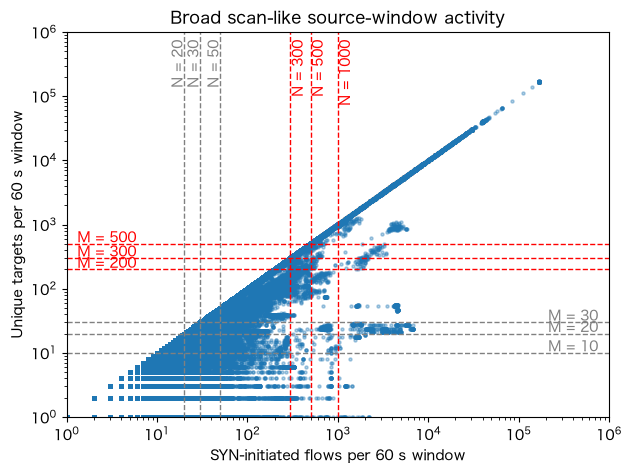

N=20, M=10: 435879 windows, 11315 sources
N=30, M=20: 291510 windows, 7018 sources
N=50, M=30: 215351 windows, 4716 sources
N=300, M=200: 56509 windows, 2388 sources
N=500, M=300: 22874 windows, 1723 sources
N=1000, M=500: 10437 windows, 246 sources


In [28]:
broad_candidates = [
    (300, 200),
    (500, 300),
    (1000, 500),
]

strict_candidates = [
    (20, 10),
    (30, 20),
    (50, 30),
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    windows['syn_initiated_flow_count'],
    windows['unique_targets'],
    alpha=0.35,
    s=5,
)
ax.set(
    xscale='log',
    yscale='log',
    xlim=broad_x_limits,
    ylim=broad_y_limits,
    xlabel='SYN-initiated flows per 60 s window',
    ylabel='Unique targets per 60 s window',
    title='Broad scan-like source-window activity',
)
for n, m in strict_candidates:
    ax.axvline(n, color='gray', linestyle='--', linewidth=1)
    ax.axhline(m, color='gray', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='gray', rotation=90, transform=ax.get_xaxis_transform(), ha='right', va='top')
    ax.text(0.98, m, f'M = {m}', color='gray', transform=ax.get_yaxis_transform(), ha='right', va='bottom')
for n, m in broad_candidates:
    ax.axvline(n, color='red', linestyle='--', linewidth=1)
    ax.axhline(m, color='red', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='red', rotation=90, transform=ax.get_xaxis_transform(), ha='left', va='top')
    ax.text(0.02, m, f'M = {m}', color='red', transform=ax.get_yaxis_transform(), ha='left', va='bottom')
plt.show()

for n, m in strict_candidates:
    matched = windows[
        (windows["syn_initiated_flow_count"] >= n)
        & (windows["unique_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )
    
for n, m in broad_candidates:
    matched = windows[
        (windows["syn_initiated_flow_count"] >= n)
        & (windows["unique_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )

## 3. Strict / 高信頼度散布図

各点は両軸で正の値を持つ1つのsource-windowです。`high_confidence_probe_pattern_count` は、リポジトリ実装に従い、観測された正のTCPパターン `syn_to_rst`（`sin_to_rst` ではありません）と `syn_synack_rst` に基づきます。

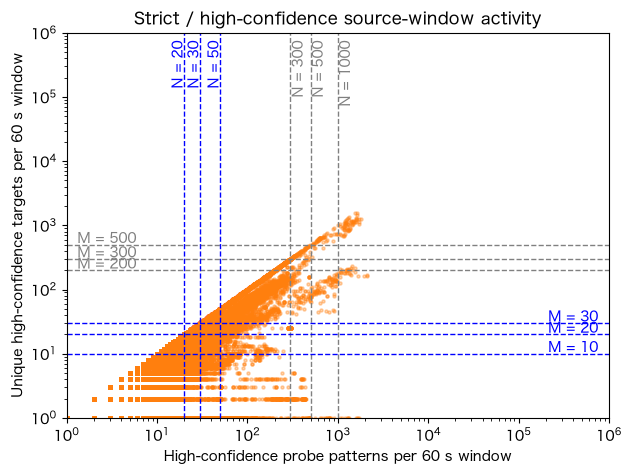

N=20, M=10: 12755 windows, 448 sources
N=30, M=20: 8536 windows, 253 sources
N=50, M=30: 5510 windows, 171 sources
N=300, M=200: 231 windows, 20 sources
N=500, M=300: 116 windows, 7 sources
N=1000, M=500: 64 windows, 4 sources


In [29]:
high_confidence = windows.loc[
    (windows['high_confidence_probe_pattern_count'] > 0)
    & (windows['unique_high_confidence_targets'] > 0)
].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    high_confidence['high_confidence_probe_pattern_count'],
    high_confidence['unique_high_confidence_targets'],
    alpha=0.35,
    color='tab:orange',
    s=5,
)
ax.set(
    xscale='log',
    yscale='log',
    xlim=broad_x_limits,
    ylim=broad_y_limits,
    xlabel='High-confidence probe patterns per 60 s window',
    ylabel='Unique high-confidence targets per 60 s window',
    title='Strict / high-confidence source-window activity',
)
for n, m in broad_candidates:
    ax.axvline(n, color='gray', linestyle='--', linewidth=1)
    ax.axhline(m, color='gray', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='gray', rotation=90, transform=ax.get_xaxis_transform(), ha='left', va='top')
    ax.text(0.02, m, f'M = {m}', color='gray', transform=ax.get_yaxis_transform(), ha='left', va='bottom')
for n, m in strict_candidates:
    ax.axvline(n, color='blue', linestyle='--', linewidth=1)
    ax.axhline(m, color='blue', linestyle='--', linewidth=1)
    ax.text(n, 0.98, f'N = {n}', color='blue', rotation=90, transform=ax.get_xaxis_transform(), ha='right', va='top')
    ax.text(0.98, m, f'M = {m}', color='blue', transform=ax.get_yaxis_transform(), ha='right', va='bottom')
plt.show()

for n, m in strict_candidates:
    matched = windows[
        (windows["high_confidence_probe_pattern_count"] >= n)
        & (windows["unique_high_confidence_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )

for n, m in broad_candidates:
    matched = windows[
        (windows["high_confidence_probe_pattern_count"] >= n)
        & (windows["unique_high_confidence_targets"] >= m)
    ]

    print(
        f"N={n}, M={m}: "
        f"{len(matched)} windows, "
        f"{matched['initial_syn_sender_ip'].nunique()} sources"
    )

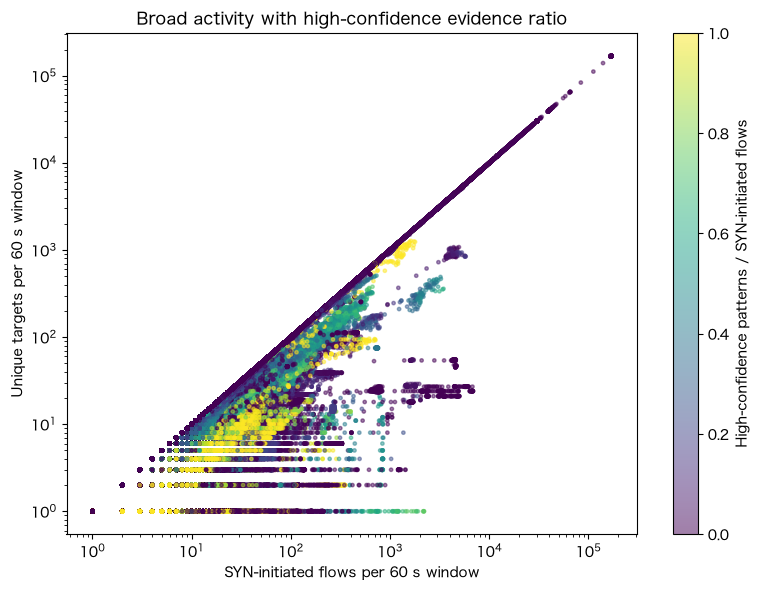

In [30]:
plot_df = windows.loc[
    (windows["syn_initiated_flow_count"] > 0)
    & (windows["unique_targets"] > 0)
].copy()

plot_df["high_confidence_ratio"] = (
    plot_df["high_confidence_probe_pattern_count"]
    / plot_df["syn_initiated_flow_count"]
)

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    plot_df["syn_initiated_flow_count"],
    plot_df["unique_targets"],
    c=plot_df["high_confidence_ratio"],
    s=6,
    alpha=0.5,
    cmap="viridis",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("SYN-initiated flows per 60 s window")
ax.set_ylabel("Unique targets per 60 s window")
ax.set_title("Broad activity with high-confidence evidence ratio")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(
    "High-confidence patterns / SYN-initiated flows"
)

plt.tight_layout()
plt.show()

## M5 provisional source-driven classification view

This section applies the provisional, configuration-driven strict thresholds to inspect M5 source-driven classification activity. Graph 1 shows why a window is classified as Strict in strict-evidence space. Graph 2 projects those exact same Strict windows into SYN-activity space. Graph 3 redraws the same Strict windows, then adds Broad evidence (`syn_only_observed`) from those already identified scan-like sources. Broad evidence is **not** an independent scan detector; it can expand Broad removal only after Strict evidence has identified a source.

Each point is a visualization activity window only. Graph 3 does **not** mean that every plotted window is removed. Actual M5 removal is capture-wide and flow-level: for a scan-like source, only `syn_to_rst` and `syn_synack_rst` flows, plus `syn_only_observed` when `broad.enabled` is true, are excluded. Established/payload and other non-probe-like flows remain.


In [31]:
from mawi_global_analysis.config import load_config
from mawi_global_analysis.scan_labels import (
    classify_strict_windows,
    derive_scan_like_sources,
)

m5_config_path = root / "configs" / "scan_source_driven_removal.yaml"
m5_config = load_config(m5_config_path)
m5_windows = pd.read_csv(windows_path)
m5_classified_windows = classify_strict_windows(m5_windows, m5_config)
m5_strict_windows = m5_classified_windows.loc[
    m5_classified_windows["strict_window"]
].copy()
scan_like_sources = derive_scan_like_sources(m5_classified_windows)
m5_source_windows = m5_classified_windows.loc[
    m5_classified_windows["initial_syn_sender_ip"].isin(scan_like_sources)
].copy()
m5_broad_evidence_windows = m5_source_windows.loc[
    m5_source_windows["no_observed_response_count"] > 0
].copy()
m5_overlap_windows = m5_strict_windows.loc[
    m5_strict_windows["no_observed_response_count"] > 0
].copy()

# Reuse the original Broad scatter limits so Graphs 2 and 3 are directly comparable.
m5_broad_x_limits = broad_x_limits
m5_broad_y_limits = broad_y_limits
m5_strict_x_limits = m5_broad_x_limits
m5_strict_y_limits = m5_broad_y_limits

print("provisional N_strict:", m5_config.scan.strict.min_pattern_count)
print("provisional M_strict:", m5_config.scan.strict.min_unique_targets)
print("strict scan-like window count:", len(m5_strict_windows))
print("scan-like source count:", len(scan_like_sources))
print("all windows from scan-like sources:", len(m5_source_windows))
print("broad-evidence windows from scan-like sources:", len(m5_broad_evidence_windows))
print("Strict/Broad-evidence overlap window count:", len(m5_overlap_windows))


provisional N_strict: 3
provisional M_strict: 2
strict scan-like window count: 134896
scan-like source count: 7478
all windows from scan-like sources: 440857
broad-evidence windows from scan-like sources: 327912
Strict/Broad-evidence overlap window count: 93315


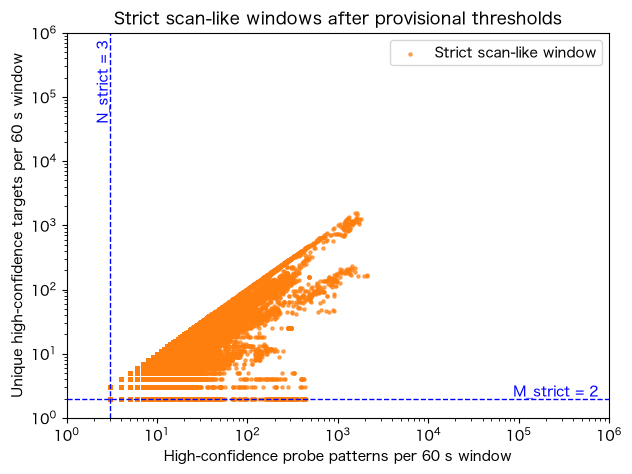

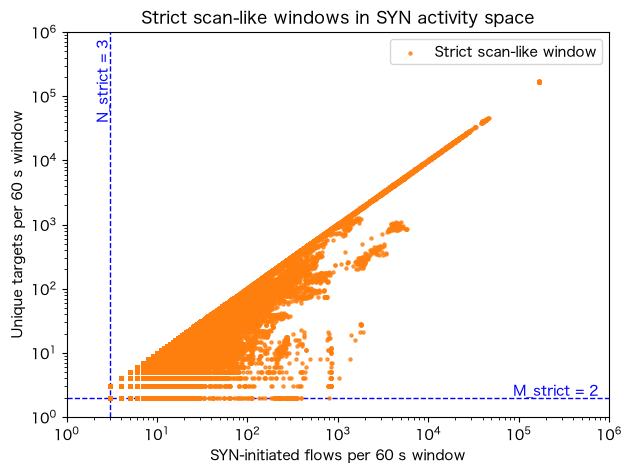

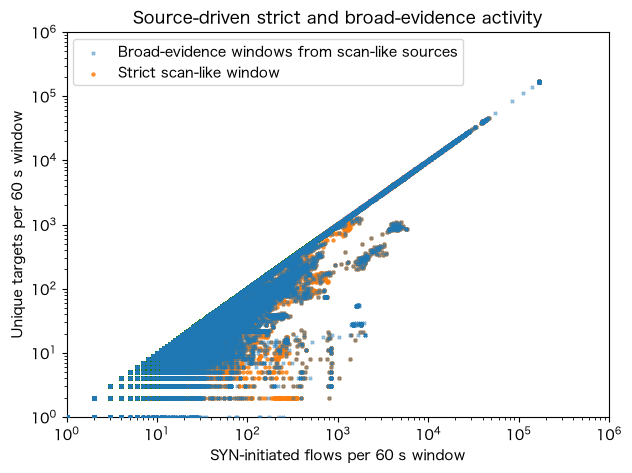

In [32]:
strict_pattern_threshold = m5_config.scan.strict.min_pattern_count
strict_target_threshold = m5_config.scan.strict.min_unique_targets

# Graph A: only windows that meet both configured Strict thresholds.
fig, ax = plt.subplots(figsize=(7, 5))
if m5_strict_windows.empty:
    ax.text(0.5, 0.5, "No Strict scan-like windows for the configured thresholds.",
            transform=ax.transAxes, ha="center", va="center")
else:
    ax.scatter(
        m5_strict_windows["high_confidence_probe_pattern_count"],
        m5_strict_windows["unique_high_confidence_targets"],
        color="tab:orange",
        alpha=0.65,
        s=5,
        label="Strict scan-like window",
    )
    ax.legend()
ax.axvline(strict_pattern_threshold, color="blue", linestyle="--", linewidth=1)
ax.axhline(strict_target_threshold, color="blue", linestyle="--", linewidth=1)
ax.text(strict_pattern_threshold, 0.98, f"N_strict = {strict_pattern_threshold}",
        color="blue", rotation=90, transform=ax.get_xaxis_transform(), ha="right", va="top")
ax.text(0.98, strict_target_threshold, f"M_strict = {strict_target_threshold}",
        color="blue", transform=ax.get_yaxis_transform(), ha="right", va="bottom")
ax.set(
    xscale="log",
    yscale="log",
    xlim=m5_strict_x_limits,
    ylim=m5_strict_y_limits,
    xlabel="High-confidence probe patterns per 60 s window",
    ylabel="Unique high-confidence targets per 60 s window",
    title="Strict scan-like windows after provisional thresholds",
)
plt.show()

m5_window_key_columns = ["initial_syn_sender_ip", "window_start", "window_end"]
m5_graph1_windows = m5_strict_windows
m5_graph2_windows = m5_strict_windows
m5_graph3_strict_windows = m5_strict_windows
m5_graph1_keys = pd.MultiIndex.from_frame(m5_graph1_windows[m5_window_key_columns])
m5_graph2_keys = pd.MultiIndex.from_frame(m5_graph2_windows[m5_window_key_columns])
m5_graph3_keys = pd.MultiIndex.from_frame(m5_graph3_strict_windows[m5_window_key_columns])
assert m5_graph1_keys.equals(m5_graph2_keys)
assert m5_graph2_keys.equals(m5_graph3_keys)
assert m5_graph2_windows[["syn_initiated_flow_count", "unique_targets"]].equals(
    m5_graph3_strict_windows[["syn_initiated_flow_count", "unique_targets"]]
)

# Graph 2: the same Strict windows, projected into the Broad/SYN activity space.
fig, ax = plt.subplots(figsize=(7, 5))
if m5_graph2_windows.empty:
    ax.text(0.5, 0.5, "No Strict scan-like windows for the configured thresholds.",
            transform=ax.transAxes, ha="center", va="center")
else:
    ax.scatter(
        m5_graph2_windows["syn_initiated_flow_count"],
        m5_graph2_windows["unique_targets"],
        color="tab:orange",
        marker="o",
        alpha=0.75,
        s=5,
        label="Strict scan-like window",
        zorder=3,
    )
    ax.legend()
ax.axvline(strict_pattern_threshold, color="blue", linestyle="--", linewidth=1)
ax.axhline(strict_target_threshold, color="blue", linestyle="--", linewidth=1)
ax.text(strict_pattern_threshold, 0.98, f"N_strict = {strict_pattern_threshold}",
        color="blue", rotation=90, transform=ax.get_xaxis_transform(), ha="right", va="top")
ax.text(0.98, strict_target_threshold, f"M_strict = {strict_target_threshold}",
        color="blue", transform=ax.get_yaxis_transform(), ha="right", va="bottom")
ax.set(
    xscale="log",
    yscale="log",
    xlim=m5_broad_x_limits,
    ylim=m5_broad_y_limits,
    xlabel="SYN-initiated flows per 60 s window",
    ylabel="Unique targets per 60 s window",
    title="Strict scan-like windows in SYN activity space",
)
plt.show()

# Graph 3: Graph 2 plus Broad evidence from sources already identified by Strict windows.
fig, ax = plt.subplots(figsize=(7, 5))
if m5_broad_evidence_windows.empty and m5_graph3_strict_windows.empty:
    ax.text(0.5, 0.5, "No scan-like source activity for the configured thresholds.",
            transform=ax.transAxes, ha="center", va="center")
else:
    if not m5_broad_evidence_windows.empty:
        ax.scatter(
            m5_broad_evidence_windows["syn_initiated_flow_count"],
            m5_broad_evidence_windows["unique_targets"],
            color="tab:blue",
            marker="x",
            alpha=0.5,
            s=5,
            zorder=4, # Ensure that the Broad-evidence points are plotted above the Strict points
            label="Broad-evidence windows from scan-like sources",
        )
    if not m5_graph3_strict_windows.empty:
        ax.scatter(
            m5_graph3_strict_windows["syn_initiated_flow_count"],
            m5_graph3_strict_windows["unique_targets"],
            color="tab:orange",
            marker="o",
            alpha=0.75,
            s=5,
            label="Strict scan-like window",
            zorder=3,
        )
    ax.legend()
ax.set(
    xscale="log",
    yscale="log",
    xlim=m5_broad_x_limits,
    ylim=m5_broad_y_limits,
    xlabel="SYN-initiated flows per 60 s window",
    ylabel="Unique targets per 60 s window",
    title="Source-driven strict and broad-evidence activity",
)
plt.show()


## Removed flows: Strict vs Broad

Strict は高信頼度 probe pattern に該当するフローを除外します。Broad は Strict に加えて、scan-like source に由来する `syn_only_observed` を追加で除外します。ここでは60秒 window数ではなく、M5 の run-local `flow_labels.csv` にある実際の一意な除外 flow 数を表示します。


In [33]:
m5_run_name = os.environ.get("MAWI_M5_RUN_NAME", m5_config.experiment.name)
flow_labels_path = root / "results" / dataset_id / m5_run_name / "flow_labels.csv"

if not flow_labels_path.is_file():
    raise FileNotFoundError(
        f"M5 flow_labels.csv が見つかりません: {flow_labels_path}. "
        "MAWI_M5_RUN_NAME を設定するか、M5 run を実行してください。"
    )

flow_labels = pd.read_csv(flow_labels_path)
required_label_columns = {"flow_id", "strict_removed", "broad_removed"}
missing_label_columns = required_label_columns - set(flow_labels.columns)
if missing_label_columns:
    raise ValueError(
        "flow_labels.csv に必要な列がありません: "
        + ", ".join(sorted(missing_label_columns))
    )
if flow_labels["flow_id"].duplicated().any():
    raise ValueError("flow_labels.csv に重複する flow_id があります")
for column in ("strict_removed", "broad_removed"):
    if not pd.api.types.is_bool_dtype(flow_labels[column]):
        raise ValueError(f"flow_labels.csv の {column} は真偽値列である必要があります")

strict_removed_count = int(flow_labels["strict_removed"].sum())
broad_removed_count = int(flow_labels["broad_removed"].sum())
broad_additional_count = int(
    (flow_labels["broad_removed"] & ~flow_labels["strict_removed"]).sum()
)

assert not (
    flow_labels["strict_removed"] & ~flow_labels["broad_removed"]
).any()
assert broad_removed_count == strict_removed_count + broad_additional_count

removal_summary = pd.DataFrame(
    {
        "Condition": ["Strict", "Broad"],
        "Strict component": [strict_removed_count, strict_removed_count],
        "Broad additional": [0, broad_additional_count],
        "Total removed": [strict_removed_count, broad_removed_count],
    }
)

print("M5 run name:", m5_run_name)
print("flow_labels path:", flow_labels_path)
display(removal_summary)

categories = ["Strict", "Broad"]
strict_component = [strict_removed_count, strict_removed_count]
broad_additional_component = [0, broad_additional_count]
total_removed = [strict_removed_count, broad_removed_count]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(categories, strict_component, label="Strict removal", color="tab:orange")
ax.bar(
    categories,
    broad_additional_component,
    bottom=strict_component,
    label="Broad additional (syn_only_observed)",
    color="tab:blue",
)
for category, total in zip(categories, total_removed):
    ax.annotate(
        f"{total:,}",
        (category, total),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )
if broad_additional_count:
    ax.text(
        "Broad",
        strict_removed_count + broad_additional_count / 2,
        f"+{broad_additional_count:,}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
ax.set(
    xlabel="Condition",
    ylabel="Removed flows",
    title="Removed flows: Strict vs Broad",
)
ax.legend()
plt.show()


FileNotFoundError: M5 flow_labels.csv が見つかりません: /Users/shunta/mawi-global-analysis/results/202604081400/scan_source_driven_removal/flow_labels.csv. MAWI_M5_RUN_NAME を設定するか、M5 run を実行してください。